<a href="https://colab.research.google.com/github/mkg6573/social_media_impact_on_life_ml_/blob/main/Supervised%20Learning%20Algorithms/SVM_GridSearchCV.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#SVM Hyperparameter Tuning

###IMPORTING LIBRARIES

In [1]:
import pandas as pd
import numpy as np

# Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Data Preprocessing
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

# Train Test Split
from sklearn.model_selection import train_test_split

# SVM
from sklearn.svm import SVC

# Pipeline
from sklearn.pipeline import Pipeline

# GridSearchCV
from sklearn.model_selection import GridSearchCV

# Evaluation Metrics
from sklearn.metrics import (

    accuracy_score,

    classification_report,

    confusion_matrix
)

# Ignore Warnings
import warnings

warnings.filterwarnings('ignore')

###LOADING DATASET

In [2]:
df = pd.read_csv(
    "/content/Cleaned_Social_media_impact_on_life_Clean_Dataset.csv"
)

# Display Dataset
df.head()

,Age,Gender,Academic_Level,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Overall_Impact
0,21,Male,Undergraduate,4.0,Facebook,No,6.7,6.8,Neutral
1,23,Female,Undergraduate,1.6,LinkedIn,No,8.6,7.6,Positive
2,22,Male,Graduate,4.6,Instagram,No,6.7,7.0,Neutral
3,18,Male,Undergraduate,7.0,Snapchat,Yes,5.4,5.3,Negative
4,24,Female,High School,7.5,Facebook,Yes,5.0,4.4,Negative


In [3]:
print("Shape of Dataset : ")

print(df.shape)

Shape of Dataset : 
(1705, 9)


In [4]:
print("\nColumns in Dataset : ")

print(df.columns)



Columns in Dataset : 
Index(['Age', 'Gender', 'Academic_Level', 'Avg_Daily_Usage_Hours',
       'Most_Used_Platform', 'Affects_Academic_Performance',
       'Sleep_Hours_Per_Night', 'Mental_Health_Score', 'Overall_Impact'],
      dtype='object')


In [5]:
print(df.columns)

print("\nMissing Values : ")

Index(['Age', 'Gender', 'Academic_Level', 'Avg_Daily_Usage_Hours',
       'Most_Used_Platform', 'Affects_Academic_Performance',
       'Sleep_Hours_Per_Night', 'Mental_Health_Score', 'Overall_Impact'],
      dtype='object')

Missing Values : 


In [6]:
print(df.isnull().sum())

Age                             0
Gender                          0
Academic_Level                  0
Avg_Daily_Usage_Hours           0
Most_Used_Platform              0
Affects_Academic_Performance    0
Sleep_Hours_Per_Night           0
Mental_Health_Score             0
Overall_Impact                  0
dtype: int64


###LABEL ENCODING

In [7]:
le = LabelEncoder()

for col in df.columns:

    if df[col].dtype == 'object':

        df[col] = le.fit_transform(
            df[col]
        )

# Display Encoded Data
df.head()

,Age,Gender,Academic_Level,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Overall_Impact
0,21,1,2,4.0,0,0,6.7,6.8,1
1,23,0,2,1.6,4,0,8.6,7.6,2
2,22,1,0,4.6,1,0,6.7,7.0,1
3,18,1,2,7.0,5,1,5.4,5.3,0
4,24,0,1,7.5,0,1,5.0,4.4,0


###FEATURE SELECTION

In [8]:
X = df.drop(

    ["Overall_Impact",
     "Mental_Health_Score"],

    axis=1
)

y = df["Overall_Impact"]

# Encode Target Variable
target_encoder = LabelEncoder()

y = target_encoder.fit_transform(y)

print("Features Shape : ")

print(X.shape)

print("\nTarget Shape : ")

print(y.shape)

print("\nFeature Columns : ")

print(X.columns)

Features Shape : 
(1705, 7)

Target Shape : 
(1705,)

Feature Columns : 
Index(['Age', 'Gender', 'Academic_Level', 'Avg_Daily_Usage_Hours',
       'Most_Used_Platform', 'Affects_Academic_Performance',
       'Sleep_Hours_Per_Night'],
      dtype='object')


###TRAIN TEST SPLIT

In [9]:
X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.2,

    random_state=42
)

print("Training Data Shape : ")

print(X_train.shape)

print("\nTesting Data Shape : ")

print(X_test.shape)

Training Data Shape : 
(1364, 7)

Testing Data Shape : 
(341, 7)


###BASELINE SVM MODEL

In [10]:
svm_pipeline = Pipeline([

    ('scaler', StandardScaler()),

    ('model', SVC())
])

# Train Model
svm_pipeline.fit(

    X_train,

    y_train
)

# Prediction
baseline_pred = svm_pipeline.predict(

    X_test
)

# Accuracy
baseline_acc = accuracy_score(

    y_test,

    baseline_pred
)

print(
    "Baseline Accuracy : ",

    baseline_acc
)

Baseline Accuracy :  0.9237536656891495


###CONFUSION MATRIX

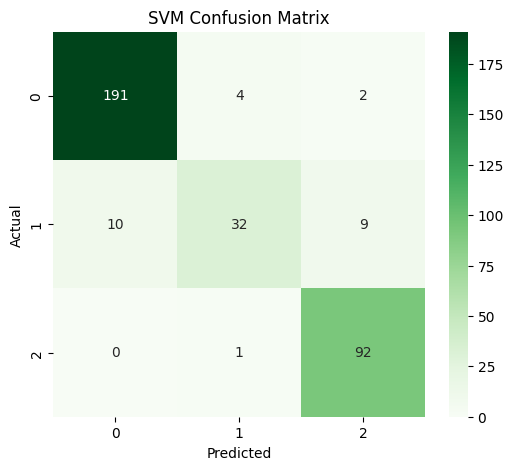

In [11]:
cm = confusion_matrix(

    y_test,

    baseline_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(

    cm,

    annot=True,

    fmt='d',

    cmap='Greens'
)

plt.title(
    "SVM Confusion Matrix"
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

###CLASSIFICATION REPORT

In [13]:
print(classification_report(y_test,baseline_pred))

              precision    recall  f1-score   support

           0       0.95      0.97      0.96       197
           1       0.86      0.63      0.73        51
           2       0.89      0.99      0.94        93

    accuracy                           0.92       341
   macro avg       0.90      0.86      0.88       341
weighted avg       0.92      0.92      0.92       341



##GRIDSEARCHCV HYPERPARAMETER TUNING

In [14]:
# Create Pipeline
svm_pipeline = Pipeline([

    ('scaler', StandardScaler()),

    ('model', SVC())
])

# Parameter Grid
param_grid = {

    'model__C': [

        0.1,

        1,

        10,

        100
    ],

    'model__kernel': [

        'linear',

        'rbf',

        'poly'
    ],

    'model__gamma': [

        'scale',

        'auto'
    ]
}

# GridSearchCV
grid_svm = GridSearchCV(

    estimator=svm_pipeline,

    param_grid=param_grid,

    cv=5,

    scoring='accuracy',

    verbose=1
)

# Train Model
grid_svm.fit(

    X_train,

    y_train
)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('model', SVC())]),
             param_grid={'model__C': [0.1, 1, 10, 100],
                         'model__gamma': ['scale', 'auto'],
                         'model__kernel': ['linear', 'rbf', 'poly']},
             scoring='accuracy', verbose=1)

###BEST PARAMETERS

In [15]:
print("Best Parameters : ")

print(grid_svm.best_params_)

print("\nBest Accuracy : ")

print(grid_svm.best_score_)

Best Parameters : 
{'model__C': 10, 'model__gamma': 'scale', 'model__kernel': 'rbf'}

Best Accuracy : 
0.9237502693385047


RESULTS TABLE

In [16]:
svm_results = pd.DataFrame(

    grid_svm.cv_results_
)

svm_results[[

    'param_model__C',

    'param_model__kernel',

    'param_model__gamma',

    'mean_test_score'
]]

,param_model__C,param_model__kernel,param_model__gamma,mean_test_score
0,0.1,linear,scale,0.860687
1,0.1,rbf,scale,0.835774
2,0.1,poly,scale,0.811573
3,0.1,linear,auto,0.860687
4,0.1,rbf,auto,0.835774
5,0.1,poly,auto,0.811573
6,1.0,linear,scale,0.866556
7,1.0,rbf,scale,0.918614
8,1.0,poly,scale,0.872425
9,1.0,linear,auto,0.866556


###VISUALIZATION

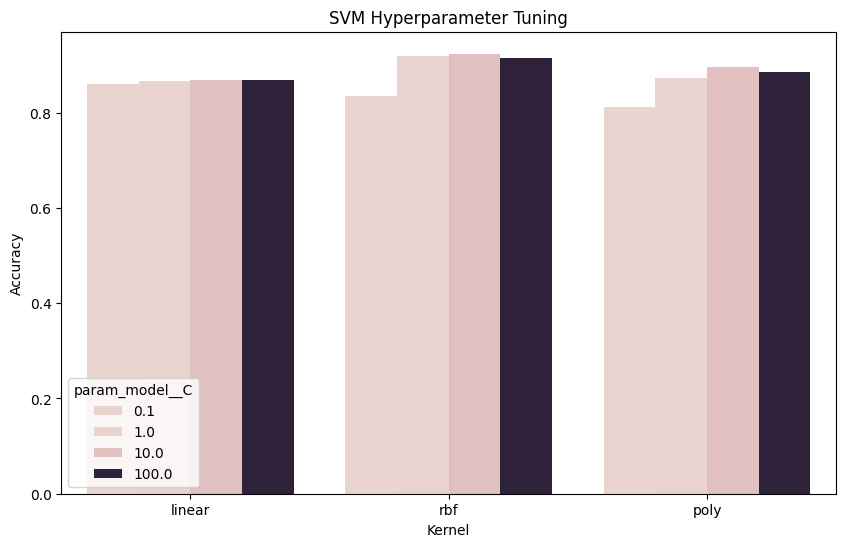

In [17]:
plt.figure(figsize=(10,6))

sns.barplot(

    x='param_model__kernel',

    y='mean_test_score',

    hue='param_model__C',

    data=svm_results
)

plt.title(
    "SVM Hyperparameter Tuning"
)

plt.xlabel("Kernel")

plt.ylabel("Accuracy")

plt.show()

###BEST MODEL PREDICTION

In [18]:
best_svm_model = grid_svm.best_estimator_

best_pred = best_svm_model.predict(

    X_test
)

best_acc = accuracy_score(

    y_test,

    best_pred
)

print(
    "Tuned Model Accuracy : ",

    best_acc
)

Tuned Model Accuracy :  0.9354838709677419


###FINAL COMPARISON

In [19]:
comparison_df = pd.DataFrame({

    'Model': ['Baseline SVM','Tuned SVM'],

    'Accuracy': [baseline_acc,best_acc]
})

comparison_df

,Model,Accuracy
0,Baseline SVM,0.923754
1,Tuned SVM,0.935484


###COMPARISON GRAPH

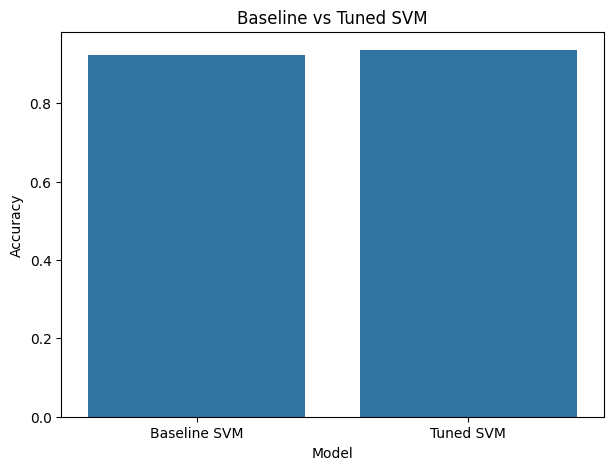

In [20]:
plt.figure(figsize=(7,5))

sns.barplot(

    x='Model',

    y='Accuracy',

    data=comparison_df
)

plt.title(
    "Baseline vs Tuned SVM"
)

plt.show()

#Analysis:

GridSearchCV was used to perform
hyperparameter tuning on the
Support Vector Machine (SVM) model.

GridSearchCV automatically tested
different combinations of C,
kernel, and gamma values using
cross-validation.
    
  In SVM:
    
    - C controls regularization and
      helps balance margin size and
      classification accuracy.
    
    - Kernel determines how the
      decision boundary is created.
    
    - Gamma controls the influence
      of individual training points.
    
  Different parameter combinations
  produced different accuracy values,
  showing that SVM performance is
  highly sensitive to hyperparameter
  tuning.
  
  The tuning process helped identify
  the optimal parameter combination
  that improved the overall prediction
  performance of the model.


In [21]:
from mlxtend.plotting import plot_decision_regions

!pip install mlxtend

In [22]:
X_vis = df[[

    'Avg_Daily_Usage_Hours',

    'Sleep_Hours_Per_Night'
]]

y_vis = y

In [23]:
X_train_vis, X_test_vis, y_train_vis, y_test_vis = train_test_split(

    X_vis,

    y_vis,

    test_size=0.2,

    random_state=42
)

In [24]:
scaler = StandardScaler()

X_train_vis = scaler.fit_transform(
    X_train_vis
)

X_test_vis = scaler.transform(
    X_test_vis
)

In [25]:

baseline_svm = SVC(

    C=0.1,

    kernel='linear'
)

baseline_svm.fit(

    X_train_vis,

    y_train_vis
)

SVC(C=0.1, kernel='linear')

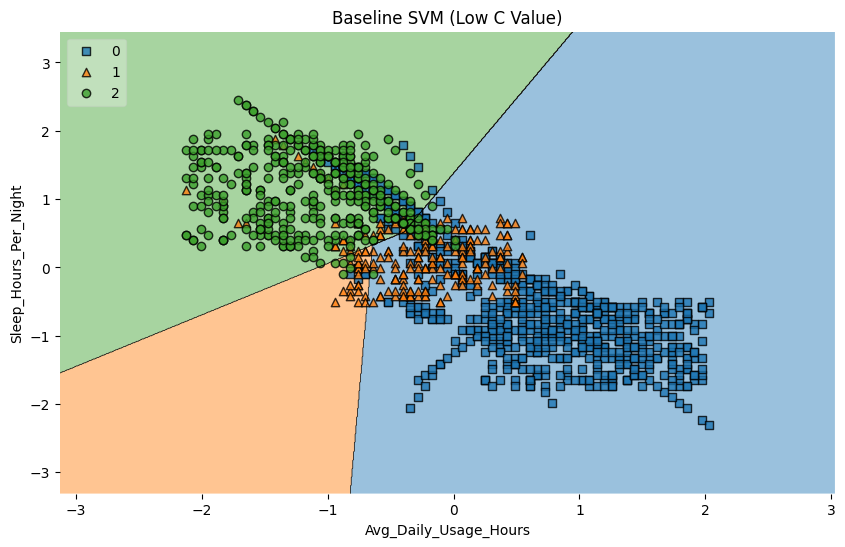

In [26]:
plt.figure(figsize=(10,6))

plot_decision_regions(

    X_train_vis,

    y_train_vis,

    clf=baseline_svm,

    legend=2
)

plt.title(
    "Baseline SVM (Low C Value)"
)

plt.xlabel(
    "Avg_Daily_Usage_Hours"
)

plt.ylabel(
    "Sleep_Hours_Per_Night"
)

plt.show()

In [27]:
tuned_svm = SVC(

    C=100,

    kernel='linear'
)

tuned_svm.fit(

    X_train_vis,

    y_train_vis
)

SVC(C=100, kernel='linear')

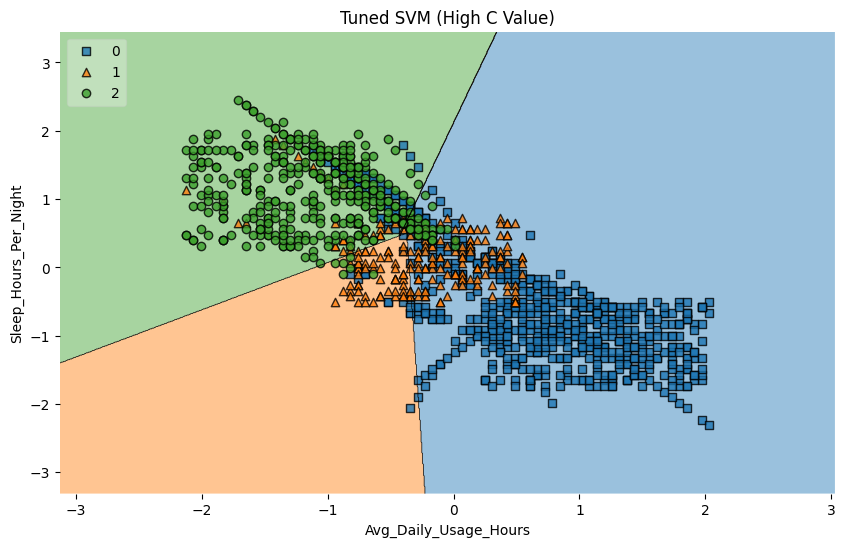

In [28]:
plt.figure(figsize=(10,6))

plot_decision_regions(

    X_train_vis,

    y_train_vis,

    clf=tuned_svm,

    legend=2
)

plt.title(
    "Tuned SVM (High C Value)"
)

plt.xlabel(
    "Avg_Daily_Usage_Hours"
)

plt.ylabel(
    "Sleep_Hours_Per_Night"
)

plt.show()

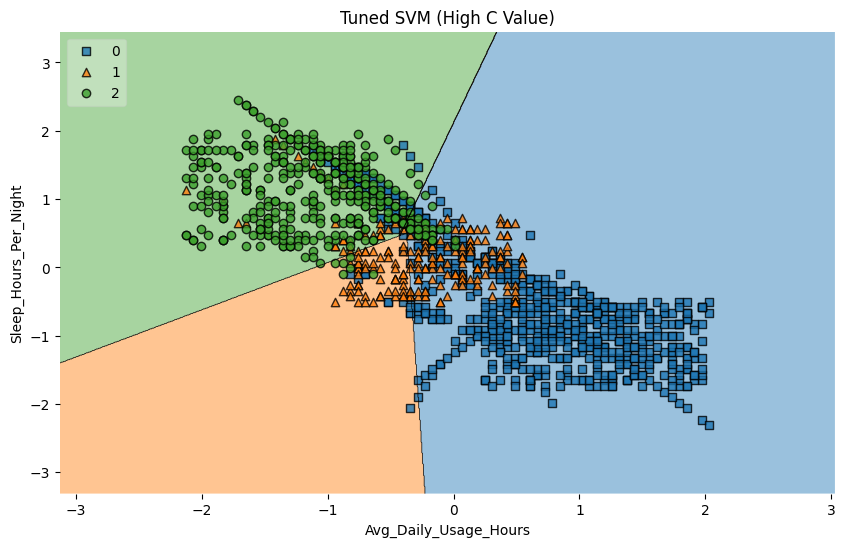

In [29]:
plt.figure(figsize=(10,6))

plot_decision_regions(

    X_train_vis,

    y_train_vis,

    clf=tuned_svm,

    legend=2
)

plt.title(
    "Tuned SVM (High C Value)"
)

plt.xlabel(
    "Avg_Daily_Usage_Hours"
)

plt.ylabel(
    "Sleep_Hours_Per_Night"
)

plt.show()

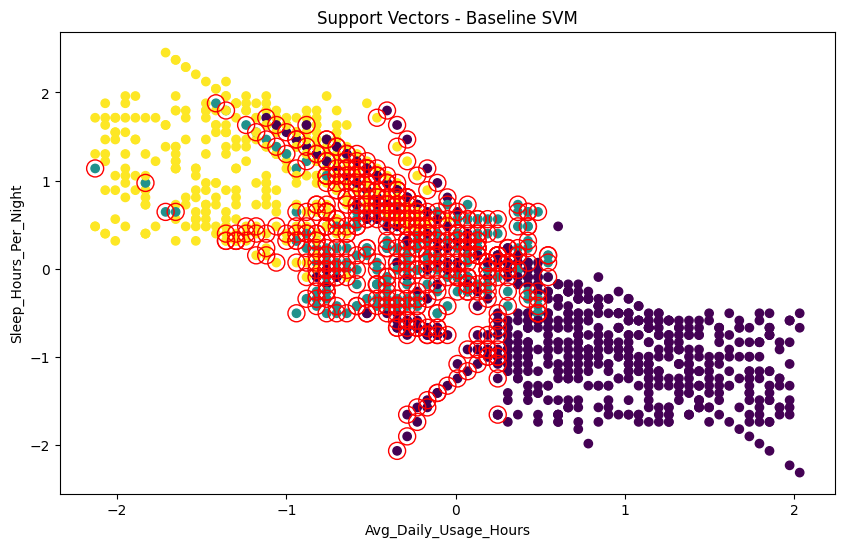

In [30]:
# baseline support vectors

plt.figure(figsize=(10,6))

plt.scatter(

    X_train_vis[:,0],

    X_train_vis[:,1],

    c=y_train_vis,

    cmap='viridis'
)

plt.scatter(

    baseline_svm.support_vectors_[:,0],

    baseline_svm.support_vectors_[:,1],

    s=150,

    facecolors='none',

    edgecolors='red'
)

plt.title(
    "Support Vectors - Baseline SVM"
)

plt.xlabel(
    "Avg_Daily_Usage_Hours"
)

plt.ylabel(
    "Sleep_Hours_Per_Night"
)

plt.show()

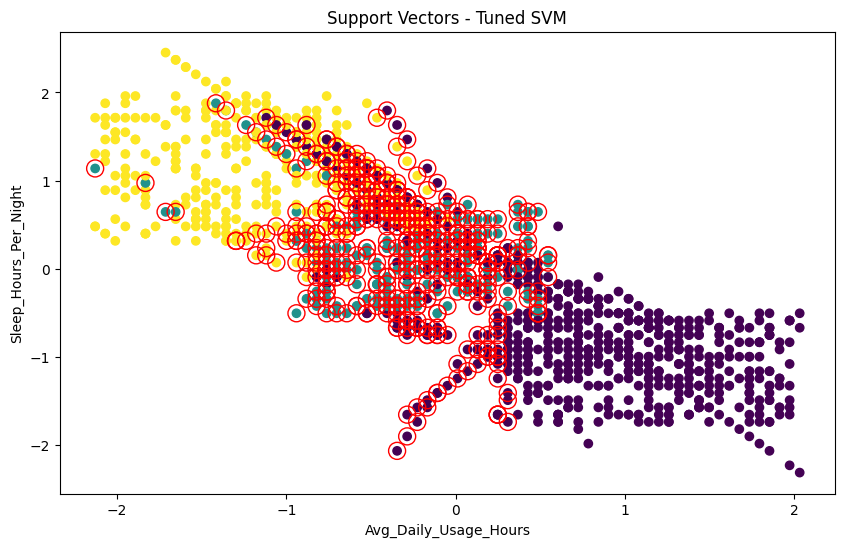

In [31]:
# TUNED SUPPORT VECTORS

plt.figure(figsize=(10,6))

plt.scatter(

    X_train_vis[:,0],

    X_train_vis[:,1],

    c=y_train_vis,

    cmap='viridis'
)

plt.scatter(

    tuned_svm.support_vectors_[:,0],

    tuned_svm.support_vectors_[:,1],

    s=150,

    facecolors='none',

    edgecolors='red'
)

plt.title(
    "Support Vectors - Tuned SVM"
)

plt.xlabel(
    "Avg_Daily_Usage_Hours"
)

plt.ylabel(
    "Sleep_Hours_Per_Night"
)

plt.show()